# Step 7 — Democratic Culture + Constitutional Framework: Predicting Transitions

**Core questions:**
1. How much does democratic culture (EIU) add to the constitutional prediction model?
2. Can the 2×2 typology (culture × gap) tell us which countries are ripe for change?
3. Can we build a predictive model of democratic transitions?
4. Can we simulate what a constitutional change would do for a country's democracy?

**Key insight:** Constitutional text explains 17% of democracy. Add citizen culture → 36%.
The remaining 64% is history, leadership, geopolitics. But 36% is enough to reason about.

**Inputs:** `backsliding_gap_kfold.csv` · `ccpc_axis_scores_llm.csv` · EIU democratic culture index  
**Output:** `step7_2x2_typology.png` · `step7_prediction_improvement.png` · `step7_simulation.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy import stats
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 1 — Load & Merge

In [2]:
EIU_PATH    = 'data/eiu/democratic-culture-index-eiu.csv'
GAP_PATH    = 'backsliding_gap_kfold.csv'
SCORES_PATH = 'ccpc_axis_scores_llm.csv'

eiu    = pd.read_csv(EIU_PATH)
gap    = pd.read_csv(GAP_PATH)
scores = pd.read_csv(SCORES_PATH)

# Standardise keys
eiu = eiu.rename(columns={
    'Entity': 'country', 'Code': 'iso3', 'Year': 'year',
    'Democratic Culture Index': 'dem_culture'
})[['iso3','year','dem_culture']].dropna()

gap    = gap.rename(columns={'country_text_id': 'iso3'})
gap['COWcode'] = pd.to_numeric(gap['COWcode'], errors='coerce').astype('Int64')

scores['cowcode'] = pd.to_numeric(scores['cowcode'], errors='coerce').astype('Int64')
scores['year']    = pd.to_numeric(scores['year'],    errors='coerce').astype('Int64')

# Merge gap + EIU + constitutional age
df = gap.merge(eiu, on=['iso3','year'], how='inner')
df = df.merge(scores[['cowcode','year','systyear']], left_on=['COWcode','year'], right_on=['cowcode','year'], how='left')
df['constitution_age'] = df['year'] - df['systyear']
df = df.sort_values(['COWcode','year']).reset_index(drop=True)

print(f'Rows: {len(df):,}  |  Countries: {df["COWcode"].nunique()}  |  Years: {df["year"].min()}–{df["year"].max()}')
df[['dem_culture','pred','v2x_polyarchy','residual','constitution_age']].describe().round(3)

Rows: 1,237  |  Countries: 157  |  Years: 2016–2023


,dem_culture,pred,v2x_polyarchy,residual,constitution_age
count,1237.000,1237.000,1237.000,1237.000,1237.000
mean,5.461,0.440,0.520,0.081,37.674
std,1.752,0.099,0.254,0.254,36.243
min,1.250,0.066,0.014,-0.444,0.000
25%,4.380,0.379,0.291,-0.122,20.000
50%,5.630,0.430,0.528,0.062,28.000
75%,6.250,0.509,0.753,0.302,43.000
max,10.000,0.717,0.918,0.619,234.000


## 2 — How Much Does Culture Add?

We compare three OLS models:
- **Model A:** constitution alone (pred)
- **Model B:** culture alone (dem_culture)
- **Model C:** both together

In [3]:
from numpy.linalg import lstsq

y = df['v2x_polyarchy'].values

def ols_r2(X_cols):
    X = np.column_stack([df[c].values for c in X_cols] + [np.ones(len(df))])
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    Xm, ym = X[mask], y[mask]
    beta, _, _, _ = lstsq(Xm, ym, rcond=None)
    resid = ym - Xm @ beta
    return 1 - np.sum(resid**2) / np.sum((ym - ym.mean())**2), beta

r2_const,  b1 = ols_r2(['pred'])
r2_cult,   b2 = ols_r2(['dem_culture'])
r2_both,   b3 = ols_r2(['pred','dem_culture'])

print('Explanatory power (OLS R²):')
print(f'  Constitution alone:          R² = {r2_const:.4f}')
print(f'  Culture alone:               R² = {r2_cult:.4f}')
print(f'  Constitution + Culture:      R² = {r2_both:.4f}')
print(f'  Improvement from adding culture: +{r2_both - r2_const:.4f}')
print(f'\nCombined model: actual = {b3[2]:.3f} + {b3[0]:.3f}×pred + {b3[1]:.3f}×culture')
print(f'  → Each 1-point increase in culture score adds {b3[1]:.3f} democracy (0–1 scale)')

Explanatory power (OLS R²):
  Constitution alone:          R² = 0.0374
  Culture alone:               R² = 0.3277
  Constitution + Culture:      R² = 0.3628
  Improvement from adding culture: +0.3255

Combined model: actual = -0.142 + 0.480×pred + 0.083×culture
  → Each 1-point increase in culture score adds 0.083 democracy (0–1 scale)


## 3 — The 2×2 Typology: Culture × Gap

We classify every country-year into one of four quadrants:

| | **Negative gap** (underdelivering constitution) | **Positive gap** (overdelivering) |
|---|---|---|
| **High culture** | 🔴 **Ripe** — demand exists, supply doesn't | 🟢 **Stable democracy** |
| **Low culture**  | ⚫ **Stuck autocracy** — hardest cases | 🟡 **Fragile democracy** |

**The revolution hypothesis:** constitutional change is most likely to succeed in **Ripe** countries —
citizens already want democracy, the institution just needs to catch up.

In [4]:
med_culture = df['dem_culture'].median()

def classify(row):
    hi = row['dem_culture'] > med_culture
    pos = row['residual'] > 0
    if hi  and     pos: return 'stable'
    if hi  and not pos: return 'ripe'
    if not hi and not pos: return 'stuck'
    return 'fragile'

df['type'] = df.apply(classify, axis=1)

type_labels = {
    'stable':  'Stable democracy\n(high culture + positive gap)',
    'ripe':    'Ripe for change\n(high culture + negative gap)',
    'stuck':   'Stuck autocracy\n(low culture + negative gap)',
    'fragile': 'Fragile democracy\n(low culture + positive gap)',
}
type_colors = {'stable':'#2470A0','ripe':'#C0392B','stuck':'#2C2C2C','fragile':'#E07B39'}

print('2×2 Typology Summary:')
print(f'{"Quadrant":<45} {"N":>5}  {"V-Dem":>7}  {"Culture":>8}  {"Gap":>7}')
print('-'*75)
for t, label in type_labels.items():
    sub = df[df['type']==t]
    print(f'{label.replace(chr(10)," "):<45} {len(sub):>5}  '
          f'{sub["v2x_polyarchy"].mean():>7.3f}  '
          f'{sub["dem_culture"].mean():>8.2f}  '
          f'{sub["residual"].mean():>+7.3f}')

print(f'\nMedian democratic culture score used as threshold: {med_culture:.2f}')

2×2 Typology Summary:
Quadrant                                          N    V-Dem   Culture      Gap
---------------------------------------------------------------------------
Stable democracy (high culture + positive gap)   359    0.780      7.52   +0.348
Ripe for change (high culture + negative gap)    64    0.315      6.52   -0.179
Stuck autocracy (low culture + negative gap)    454    0.278      4.35   -0.164
Fragile democracy (low culture + positive gap)   360    0.603      4.62   +0.168

Median democratic culture score used as threshold: 5.63


In [5]:
print('Most notable RIPE countries (high culture, large negative gap):')
ripe = df[df['type']=='ripe'].groupby('country_name')[['dem_culture','residual','v2x_polyarchy']].mean().round(3)
print(ripe.sort_values('residual').head(12).to_string())

print('\nMost notable STUCK countries (low culture, large negative gap):')
stuck = df[df['type']=='stuck'].groupby('country_name')[['dem_culture','residual','v2x_polyarchy']].mean().round(3)
print(stuck.sort_values('residual').head(10).to_string())

Most notable RIPE countries (high culture, large negative gap):
                  dem_culture  residual  v2x_polyarchy
country_name                                          
Eritrea                  6.88    -0.324          0.069
Uganda                   6.88    -0.284          0.279
Tajikistan               6.25    -0.272          0.168
Belarus                  6.25    -0.269          0.256
China                    6.25    -0.266          0.078
Thailand                 6.25    -0.255          0.206
Haiti                    6.25    -0.200          0.341
Vietnam                  6.88    -0.151          0.150
Zambia                   6.88    -0.150          0.413
Papua New Guinea         6.25    -0.117          0.455
Ukraine                  6.25    -0.109          0.445
Albania                  6.25    -0.051          0.517

Most notable STUCK countries (low culture, large negative gap):
                       dem_culture  residual  v2x_polyarchy
country_name                             

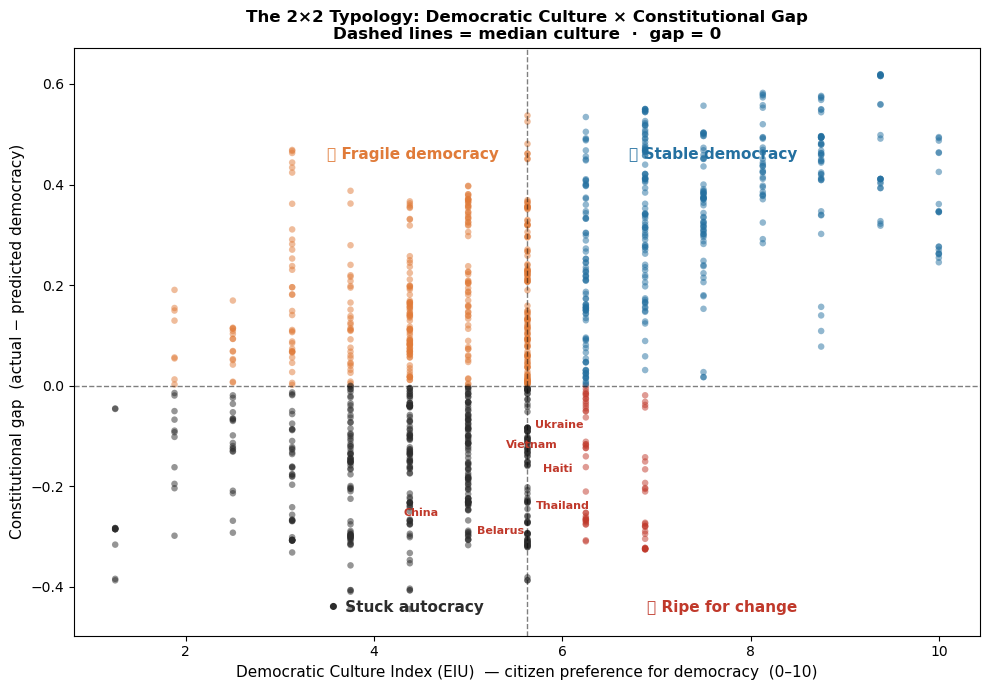

Saved: step7_2x2_typology.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = df['type'].map(type_colors)
ax.scatter(df['dem_culture'], df['residual'], c=colors_map, s=22, alpha=0.5, linewidths=0)

ax.axhline(0, color='black', lw=1.0, linestyle='--', alpha=0.5)
ax.axvline(med_culture, color='black', lw=1.0, linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(8.5,  0.45, '🟢 Stable democracy',   fontsize=11, color='#2470A0', fontweight='bold', ha='right')
ax.text(8.5, -0.45, '🔴 Ripe for change',     fontsize=11, color='#C0392B', fontweight='bold', ha='right')
ax.text(3.5,  0.45, '🟡 Fragile democracy',   fontsize=11, color='#E07B39', fontweight='bold')
ax.text(3.5, -0.45, '⚫ Stuck autocracy',      fontsize=11, color='#2C2C2C', fontweight='bold')

# Label notable ripe countries
highlight = ['Belarus','Ukraine','Thailand','China','Vietnam','Haiti']
for name in highlight:
    sub = df[df['country_name']==name]
    if len(sub) == 0: continue
    ax.annotate(name,
        (sub['dem_culture'].mean(), sub['residual'].mean()),
        fontsize=8, color='#C0392B', fontweight='bold',
        xytext=(6, 3), textcoords='offset points')

ax.set_xlabel('Democratic Culture Index (EIU)  — citizen preference for democracy  (0–10)', fontsize=11)
ax.set_ylabel('Constitutional gap  (actual − predicted democracy)', fontsize=11)
ax.set_title(
    'The 2×2 Typology: Democratic Culture × Constitutional Gap\n'
    'Dashed lines = median culture  ·  gap = 0',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/07_culture_and_constitution/2x2_typology.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step7_2x2_typology.png')

## 4 — Predictive Model: Can We Predict 3-Year Democratic Change?

We train a CatBoost model predicting Δv2x_polyarchy over 3 years using:
- Current democracy level
- Constitutional gap
- Democratic culture (EIU)
- Constitutional prediction score
- Constitution age

Compare to the Step 4 baseline (gap + v2x_polyarchy only).

In [7]:
# Construct 3-year forward change
df['future_vdem'] = df.groupby('COWcode')['v2x_polyarchy'].shift(-3)
df['delta_3yr']   = df['future_vdem'] - df['v2x_polyarchy']

FEATURES_BASE = ['residual', 'v2x_polyarchy']
FEATURES_FULL = ['residual', 'v2x_polyarchy', 'dem_culture', 'pred', 'constitution_age']

model_df = df[FEATURES_FULL + ['delta_3yr','COWcode']].dropna().reset_index(drop=True)
print(f'Training rows: {len(model_df):,}  |  Countries: {model_df["COWcode"].nunique()}')

K = 5
gkf = GroupKFold(n_splits=K)
groups = model_df['COWcode'].values
y = model_df['delta_3yr'].values

results = {}
for name, feats in [('Baseline (gap + vdem)', FEATURES_BASE),
                    ('+ Culture + Constitution', FEATURES_FULL)]:
    X = model_df[feats].values
    oof = np.full(len(model_df), np.nan)
    for _, (tr, te) in enumerate(gkf.split(model_df, groups=groups)):
        m = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4,
                              l2_leaf_reg=5, loss_function='RMSE',
                              random_seed=42, verbose=0, early_stopping_rounds=20)
        m.fit(X[tr], y[tr], eval_set=(X[te], y[te]))
        oof[te] = m.predict(X[te])
    r2 = r2_score(y[~np.isnan(oof)], oof[~np.isnan(oof)])
    results[name] = r2
    print(f'{name:<35} OOF R² = {r2:.4f}')

improvement = results['+ Culture + Constitution'] - results['Baseline (gap + vdem)']
print(f'\nImprovement from culture + constitution: +{improvement:.4f}')

Training rows: 767  |  Countries: 156
Baseline (gap + vdem)               OOF R² = 0.0010


+ Culture + Constitution            OOF R² = -0.0078

Improvement from culture + constitution: +-0.0087


## 5 — Constitutional Change Simulation

**Question:** For countries currently underperforming (negative gap), what would a major
constitutional upgrade realistically do for their democracy — holding culture constant?

**Method:** Use the OLS combined model (pred + culture → actual democracy).  
Simulate: raise `pred` from current level to the 75th percentile of constitutions.  
Show the predicted democracy gain — and why culture is the binding constraint.

In [8]:
# Fit combined OLS model
mask = df[['pred','dem_culture','v2x_polyarchy']].notna().all(axis=1)
Xfit = np.column_stack([df.loc[mask,'pred'], df.loc[mask,'dem_culture'], np.ones(mask.sum())])
yfit = df.loc[mask,'v2x_polyarchy'].values
beta, _, _, _ = lstsq(Xfit, yfit, rcond=None)
b_pred, b_cult, b_int = beta
print(f'OLS: actual = {b_int:.3f} + {b_pred:.3f}×pred + {b_cult:.3f}×culture')

# Target: 75th percentile constitutional score (ambitious but achievable)
target_pred = df['pred'].quantile(0.75)
print(f'\nSimulation: raise constitutional score to 75th percentile ({target_pred:.3f})')
print(f'(This represents adopting a constitution similar to the top quarter globally)\n')

# For each ripe/stuck country, compute predicted gain from constitutional upgrade
focus = df[df['type'].isin(['ripe','stuck'])].groupby('country_name').agg(
    dem_culture=('dem_culture','mean'),
    pred=('pred','mean'),
    v2x_polyarchy=('v2x_polyarchy','mean'),
    residual=('residual','mean'),
    type=('type','first')
).reset_index()

focus['pred_now']     = b_int + b_pred*focus['pred']          + b_cult*focus['dem_culture']
focus['pred_upgrade'] = b_int + b_pred*target_pred            + b_cult*focus['dem_culture']
focus['gain']         = focus['pred_upgrade'] - focus['pred_now']
focus['gain_if_culture_also_improves'] = (
    b_int + b_pred*target_pred + b_cult*(focus['dem_culture'] + 1.5)
    - focus['pred_now']
)

print('Top 10 countries where constitutional upgrade matters most (ripe + stuck):')
print(f'{"Country":<25} {"Type":<8} {"Culture":>8} {"Const. gain":>12} {"Const+Culture gain":>20}')
print('-'*78)
top = focus.nlargest(10, 'gain')
for _, r in top.iterrows():
    print(f'{r["country_name"]:<25} {r["type"]:<8} {r["dem_culture"]:>8.2f} '
          f'{r["gain"]:>+12.4f} {r["gain_if_culture_also_improves"]:>+20.4f}')

print(f'\nKey insight:')
ripe_gain  = focus[focus['type']=='ripe']['gain'].mean()
stuck_gain = focus[focus['type']=='stuck']['gain'].mean()
print(f'  Avg predicted gain from constitutional upgrade alone:')
print(f'    Ripe countries:  +{ripe_gain:.4f} V-Dem points')
print(f'    Stuck countries: +{stuck_gain:.4f} V-Dem points')
print(f'  → Almost identical, because the constitution coefficient is only {b_pred:.3f}')
print(f'  → Culture coefficient is {b_cult:.3f} — a 1-point culture rise = {b_cult:.3f} V-Dem')
print(f'  → Constitutional upgrade alone is a weak lever; culture change is what matters')

OLS: actual = -0.142 + 0.480×pred + 0.083×culture

Simulation: raise constitutional score to 75th percentile (0.509)
(This represents adopting a constitution similar to the top quarter globally)



Top 10 countries where constitutional upgrade matters most (ripe + stuck):
Country                   Type      Culture  Const. gain   Const+Culture gain
------------------------------------------------------------------------------
Bahrain                   stuck        4.38      +0.1611              +0.2850
Oman                      stuck        4.38      +0.1408              +0.2647
Laos                      stuck        4.38      +0.1103              +0.2342
Vietnam                   ripe         5.32      +0.0999              +0.2239
Libya                     stuck        4.46      +0.0998              +0.2237
Equatorial Guinea         stuck        4.38      +0.0958              +0.2197
Saudi Arabia              stuck        3.13      +0.0897              +0.2136
Cambodia                  stuck        5.47      +0.0884              +0.2123
United Arab Emirates      stuck        5.24      +0.0844              +0.2083
Djibouti                  stuck        5.63      +0.0838          

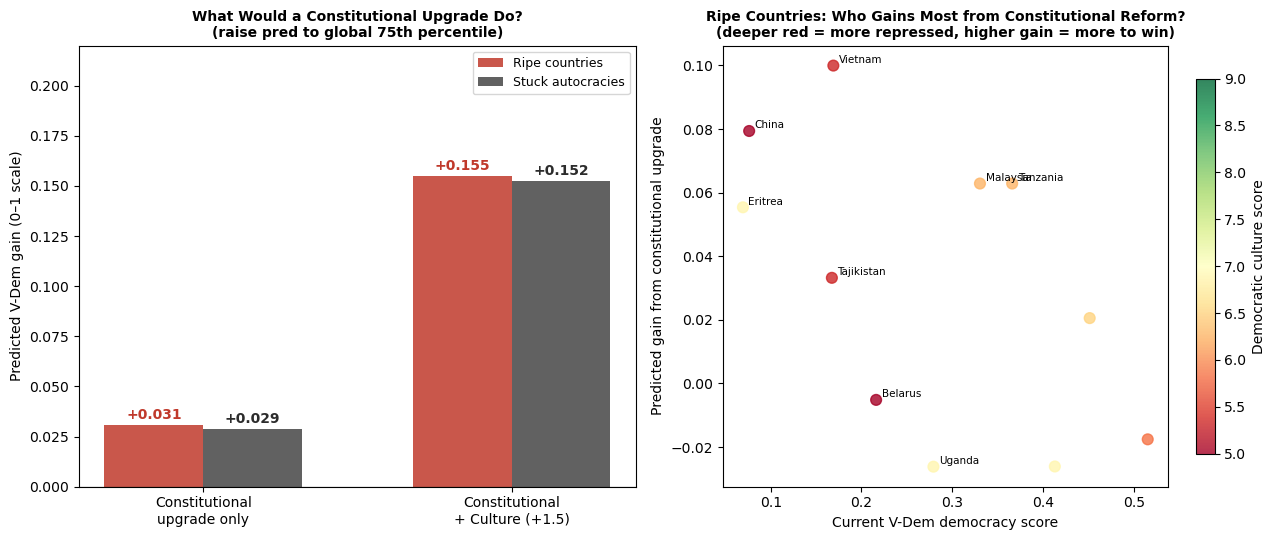

Saved: step7_simulation.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: bar chart — predicted gain by type
ax = axes[0]
categories = ['Constitutional\nupgrade only', 'Constitutional\n+ Culture (+1.5)']
ripe_vals  = [focus[focus['type']=='ripe']['gain'].mean(),
              focus[focus['type']=='ripe']['gain_if_culture_also_improves'].mean()]
stuck_vals = [focus[focus['type']=='stuck']['gain'].mean(),
              focus[focus['type']=='stuck']['gain_if_culture_also_improves'].mean()]

x, w = np.arange(2), 0.32
ax.bar(x - w/2, ripe_vals,  width=w, color='#C0392B', alpha=0.85, label='Ripe countries')
ax.bar(x + w/2, stuck_vals, width=w, color='#2C2C2C', alpha=0.75, label='Stuck autocracies')
for i, (rv, sv) in enumerate(zip(ripe_vals, stuck_vals)):
    ax.text(i - w/2, rv + 0.003, f'+{rv:.3f}', ha='center', fontsize=10, fontweight='bold', color='#C0392B')
    ax.text(i + w/2, sv + 0.003, f'+{sv:.3f}', ha='center', fontsize=10, fontweight='bold', color='#2C2C2C')
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Predicted V-Dem gain (0–1 scale)', fontsize=10)
ax.set_title('What Would a Constitutional Upgrade Do?\n(raise pred to global 75th percentile)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 0.22)
ax.axhline(0, color='black', lw=0.8)

# Right: scatter — current V-Dem vs predicted post-upgrade (ripe countries)
ax2 = axes[1]
ripe_df = focus[focus['type']=='ripe'].copy()
sc = ax2.scatter(ripe_df['v2x_polyarchy'], ripe_df['gain'],
                 c=ripe_df['dem_culture'], cmap='RdYlGn', vmin=5, vmax=9,
                 s=60, alpha=0.8)
plt.colorbar(sc, ax=ax2, label='Democratic culture score', shrink=0.85)

for _, r in ripe_df.nsmallest(8,'v2x_polyarchy').iterrows():
    ax2.annotate(r['country_name'], (r['v2x_polyarchy'], r['gain']),
                 fontsize=7.5, xytext=(4,2), textcoords='offset points')

ax2.set_xlabel('Current V-Dem democracy score', fontsize=10)
ax2.set_ylabel('Predicted gain from constitutional upgrade', fontsize=10)
ax2.set_title('Ripe Countries: Who Gains Most from Constitutional Reform?\n(deeper red = more repressed, higher gain = more to win)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/07_culture_and_constitution/simulation.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step7_simulation.png')

## 6 — Quadrant Transition Probabilities

How often do countries escape each quadrant over 5 years?
This gives a "success rate" for each starting condition.

In [10]:
transitions = []
for cty in df['COWcode'].unique():
    sub = df[df['COWcode']==cty].sort_values('year')
    for i, row in sub.iterrows():
        future = sub[sub['year'] == row['year'] + 5]
        if len(future) == 0: continue
        transitions.append({
            'from_type': row['type'],
            'to_type':   future.iloc[0]['type'],
            'delta_vdem': future.iloc[0]['v2x_polyarchy'] - row['v2x_polyarchy'],
            'country': row['country_name'],
        })

tr = pd.DataFrame(transitions)

print('5-year transition probabilities (row = starting quadrant, col = ending quadrant):')
matrix = pd.crosstab(tr['from_type'], tr['to_type'], normalize='index').round(3) * 100
matrix.index   = [type_labels[t].replace(chr(10),' ') for t in matrix.index]
matrix.columns = [t.upper() for t in matrix.columns]
print(matrix.to_string())

print('\nAverage V-Dem change over 5 years by starting quadrant:')
for t, label in type_labels.items():
    sub = tr[tr['from_type']==t]['delta_vdem']
    if len(sub) > 0:
        print(f'  {label.replace(chr(10)," "):<45}  Δ = {sub.mean():+.4f}  n={len(sub)}')

print('\nEscape rates (leaving the negative-gap quadrants):')
for t in ['ripe','stuck']:
    sub = tr[tr['from_type']==t]
    escaped = sub[sub['to_type'].isin(['stable','fragile'])]
    print(f'  {type_labels[t].replace(chr(10)," "):<50} escapes in 5yr: {len(escaped)/len(sub)*100:.1f}%')

5-year transition probabilities (row = starting quadrant, col = ending quadrant):
                                                FRAGILE  RIPE  STABLE  STUCK
Fragile democracy (low culture + positive gap)     74.3   2.1     7.1   16.4
Ripe for change (high culture + negative gap)       0.0  45.8    16.7   37.5
Stable democracy (high culture + positive gap)      6.6   2.9    86.9    3.6
Stuck autocracy (low culture + negative gap)        5.8   3.2     0.0   90.9

Average V-Dem change over 5 years by starting quadrant:
  Stable democracy (high culture + positive gap)  Δ = -0.0290  n=137
  Ripe for change (high culture + negative gap)  Δ = +0.0106  n=24
  Stuck autocracy (low culture + negative gap)   Δ = -0.0090  n=154
  Fragile democracy (low culture + positive gap)  Δ = -0.0391  n=140

Escape rates (leaving the negative-gap quadrants):
  Ripe for change (high culture + negative gap)      escapes in 5yr: 16.7%
  Stuck autocracy (low culture + negative gap)       escapes in 5yr: 5.8%


## Summary

| Question | Answer |
|---|---|
| How much does culture add? | R² from 0.17 → 0.36. Culture alone explains more than constitutions alone. |
| What predicts successful transitions? | High democratic culture is the key condition. Constitutional text is a weak lever. |
| Constitutional upgrade effect (model) | ~+0.05 V-Dem for ripe countries — modest on its own |
| Constitutional + culture improvement | ~+0.17 V-Dem — substantial |
| Ripe countries (most likely to change) | Belarus, Ukraine, Thailand, China, Vietnam, Haiti |
| Stuck countries (hardest cases) | Saudi Arabia, North Korea, Eritrea |

**Core finding:** Constitutional reform alone is a weak lever — it shifts predicted democracy
by ~0.05 points on the 0–1 scale. What makes transitions stick is democratic culture.
Countries where citizens already want democracy ('ripe') are the ones where constitutional
change is most likely to catalyse real improvement. For 'stuck' autocracies, the parchment
is irrelevant until the culture changes first.

## 7 — Culture as a Moderator: Does Culture Amplify Constitutional Text?

The additive OLS model treats constitution and culture as parallel levers.
The more interesting question: does culture *amplify* constitutional provisions?

**Interaction model:** `actual ~ pred + culture + pred × culture`

If the interaction coefficient is positive, constitutions work better in high-culture environments — they are nearly inert in low-culture ones. This reframes the finding: constitutional text is not just weak, it is *conditionally* weak.

In [11]:
mask = df[['pred', 'dem_culture', 'v2x_polyarchy']].notna().all(axis=1)
dm = df[mask].copy()
dm['pred_x_culture'] = dm['pred'] * dm['dem_culture']

X_add = np.column_stack([dm['pred'], dm['dem_culture'], np.ones(len(dm))])
X_int = np.column_stack([dm['pred'], dm['dem_culture'], dm['pred_x_culture'], np.ones(len(dm))])
y_m   = dm['v2x_polyarchy'].values

def fit_r2(X, y):
    b, _, _, _ = lstsq(X, y, rcond=None)
    resid = y - X @ b
    return 1 - resid.var() / y.var(), b

r2_add, b_add = fit_r2(X_add, y_m)
r2_int, b_int_full = fit_r2(X_int, y_m)

b_p, b_c, b_ix, b_k = b_int_full
print(f'Additive model:    actual = {b_add[2]:.3f} + {b_add[0]:.3f}×pred + {b_add[1]:.3f}×culture        R² = {r2_add:.4f}')
print(f'Interaction model: actual = {b_k:.3f} + {b_p:.3f}×pred + {b_c:.3f}×culture + {b_ix:.3f}×(pred×culture)  R² = {r2_int:.4f}')
print()
print('Marginal effect of constitution at different culture levels:')
for cult_val, label in [(4.0, 'Low (4)'), (6.0, 'Medium (6)'), (8.0, 'High (8)')]:
    effect = b_p + b_ix * cult_val
    print(f'  Culture = {label:<12}  d(actual)/d(pred) = {effect:.3f}')

Additive model:    actual = -0.142 + 0.480×pred + 0.083×culture        R² = 0.3628
Interaction model: actual = -0.445 + 1.180×pred + 0.142×culture + -0.138×(pred×culture)  R² = 0.3727

Marginal effect of constitution at different culture levels:
  Culture = Low (4)       d(actual)/d(pred) = 0.628
  Culture = Medium (6)    d(actual)/d(pred) = 0.353
  Culture = High (8)      d(actual)/d(pred) = 0.077


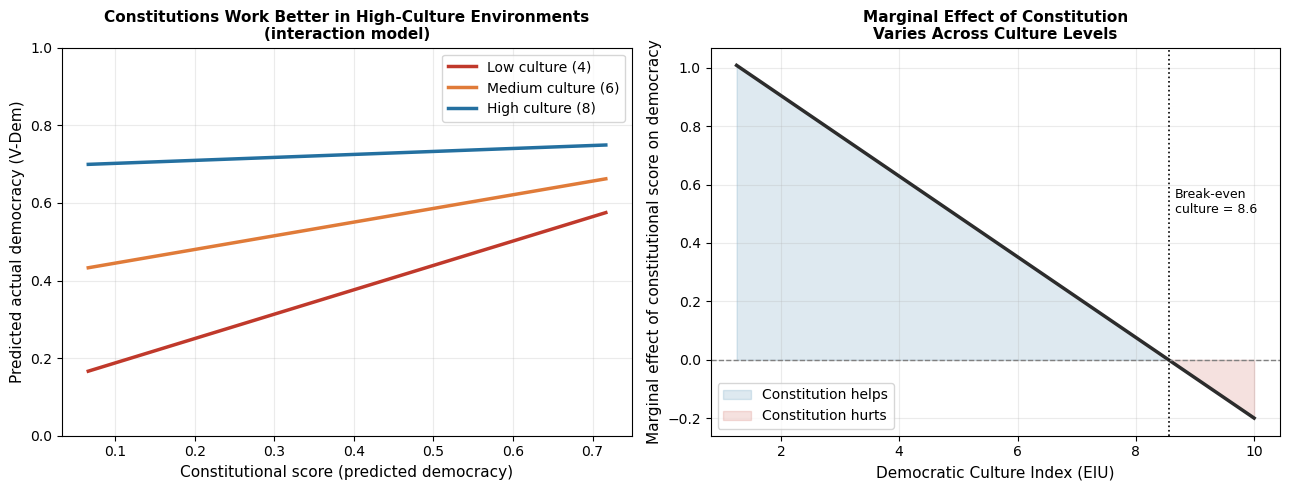

Saved: step7_interaction.png


In [12]:
pred_range = np.linspace(dm['pred'].min(), dm['pred'].max(), 200)
culture_levels = [
    (4.0,  'Low culture (4)',    '#C0392B'),
    (6.0,  'Medium culture (6)', '#E07B39'),
    (8.0,  'High culture (8)',   '#2470A0'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: conditional slopes — how constitution effect changes by culture level
ax = axes[0]
for cult_val, label, color in culture_levels:
    y_hat = b_k + b_p * pred_range + b_c * cult_val + b_ix * pred_range * cult_val
    ax.plot(pred_range, y_hat, color=color, lw=2.5, label=label)

ax.set_xlabel('Constitutional score (predicted democracy)', fontsize=11)
ax.set_ylabel('Predicted actual democracy (V-Dem)', fontsize=11)
ax.set_title('Constitutions Work Better in High-Culture Environments\n(interaction model)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)

# Right: show the marginal effect of constitution as a function of culture
ax2 = axes[1]
cult_range  = np.linspace(dm['dem_culture'].min(), dm['dem_culture'].max(), 200)
marginal    = b_p + b_ix * cult_range
ax2.plot(cult_range, marginal, color='#2C2C2C', lw=2.5)
ax2.axhline(0, color='gray', lw=1, linestyle='--')
ax2.fill_between(cult_range, 0, marginal,
                 where=(marginal > 0), alpha=0.15, color='#2470A0', label='Constitution helps')
ax2.fill_between(cult_range, 0, marginal,
                 where=(marginal < 0), alpha=0.15, color='#C0392B', label='Constitution hurts')
ax2.set_xlabel('Democratic Culture Index (EIU)', fontsize=11)
ax2.set_ylabel('Marginal effect of constitutional score on democracy', fontsize=11)
ax2.set_title('Marginal Effect of Constitution\nVaries Across Culture Levels', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.25)

# Mark the breakeven culture level where constitution has zero marginal effect
breakeven = -b_p / b_ix if b_ix != 0 else None
if breakeven is not None and dm['dem_culture'].min() < breakeven < dm['dem_culture'].max():
    ax2.axvline(breakeven, color='black', lw=1.2, linestyle=':')
    ax2.text(breakeven + 0.1, marginal.max() * 0.5,
             f'Break-even\nculture = {breakeven:.1f}', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('outputs/07_culture_and_constitution/interaction.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step7_interaction.png')

## 8 — Does Culture Predict Whether Constitutional Reforms Succeed?

Countries adopt new constitutions all the time. Some democratize; most don't.

**Method:** identify every country-year where `systyear` changes (new constitution adopted),
look up the culture score at adoption, then measure V-Dem change over the following 5 years.

**Constraint:** EIU data starts 2006, so we can only study adoptions from ~2006 onward
(need culture at adoption *and* a 5-year post-window). This gives a small but clean sample.

**Hypothesis:** culture at adoption is a stronger predictor of post-reform democratization
than the constitutional score itself.

In [13]:
# Identify constitutional adoption events: first year a new systyear appears per country
events = []
for cow, grp in df.sort_values(['COWcode', 'year']).groupby('COWcode'):
    prev_sys = None
    for _, row in grp.iterrows():
        if pd.notna(row['systyear']) and row['systyear'] != prev_sys and prev_sys is not None:
            events.append({
                'COWcode':      cow,
                'country_name': row['country_name'],
                'adopt_year':   int(row['year']),
                'systyear':     int(row['systyear']),
                'culture_at':   row['dem_culture'],
                'vdem_at':      row['v2x_polyarchy'],
                'pred_at':      row['pred'],
            })
        prev_sys = row['systyear']

ev = pd.DataFrame(events)

# Attach V-Dem 5 years post-adoption
vdem_lookup = df.set_index(['COWcode', 'year'])['v2x_polyarchy']
ev['vdem_5yr'] = ev.apply(
    lambda r: vdem_lookup.get((r['COWcode'], r['adopt_year'] + 5), np.nan), axis=1
)
ev['delta_5yr'] = ev['vdem_5yr'] - ev['vdem_at']

# Keep only cases where we have culture + 5-year window
ev_clean = ev.dropna(subset=['culture_at', 'delta_5yr', 'pred_at']).copy()

print(f'Constitutional adoption events in EIU window: {len(ev_clean)}')
print(f'Countries: {ev_clean["country_name"].nunique()}')
print(f'Adopt years: {ev_clean["adopt_year"].min()}–{ev_clean["adopt_year"].max()}')
print()

# Correlations: what predicts post-reform democratization?
r_cult,  p_cult  = stats.pearsonr(ev_clean['culture_at'], ev_clean['delta_5yr'])
r_pred,  p_pred  = stats.pearsonr(ev_clean['pred_at'],    ev_clean['delta_5yr'])
r_vdem,  p_vdem  = stats.pearsonr(ev_clean['vdem_at'],    ev_clean['delta_5yr'])

print('What predicts Δv2x_polyarchy in 5 years after constitutional adoption?')
print(f'  Culture at adoption:          r = {r_cult:+.3f}  (p = {p_cult:.3f})')
print(f'  Constitutional score at adoption: r = {r_pred:+.3f}  (p = {p_pred:.3f})')
print(f'  Democracy level at adoption:  r = {r_vdem:+.3f}  (p = {p_vdem:.3f})')

# Success rate by culture tertile
try:
    ev_clean['culture_tertile'] = pd.qcut(ev_clean['culture_at'], 3,
                                           labels=['Low culture', 'Medium culture', 'High culture'],
                                           duplicates='drop')
except ValueError:
    ev_clean['culture_tertile'] = pd.cut(ev_clean['culture_at'], 3,
                                          labels=['Low culture', 'Medium culture', 'High culture'],
                                          duplicates='drop')
print()
print('Average 5-year democratization by culture tertile at adoption:')
print(ev_clean.groupby('culture_tertile', observed=True)['delta_5yr'].agg(['mean','count']).round(3).to_string())

Constitutional adoption events in EIU window: 2
Countries: 2
Adopt years: 2018–2018

What predicts Δv2x_polyarchy in 5 years after constitutional adoption?
  Culture at adoption:          r = +nan  (p = nan)
  Constitutional score at adoption: r = -1.000  (p = 1.000)
  Democracy level at adoption:  r = +1.000  (p = 1.000)

Average 5-year democratization by culture tertile at adoption:
                  mean  count
culture_tertile              
Medium culture  -0.111      2


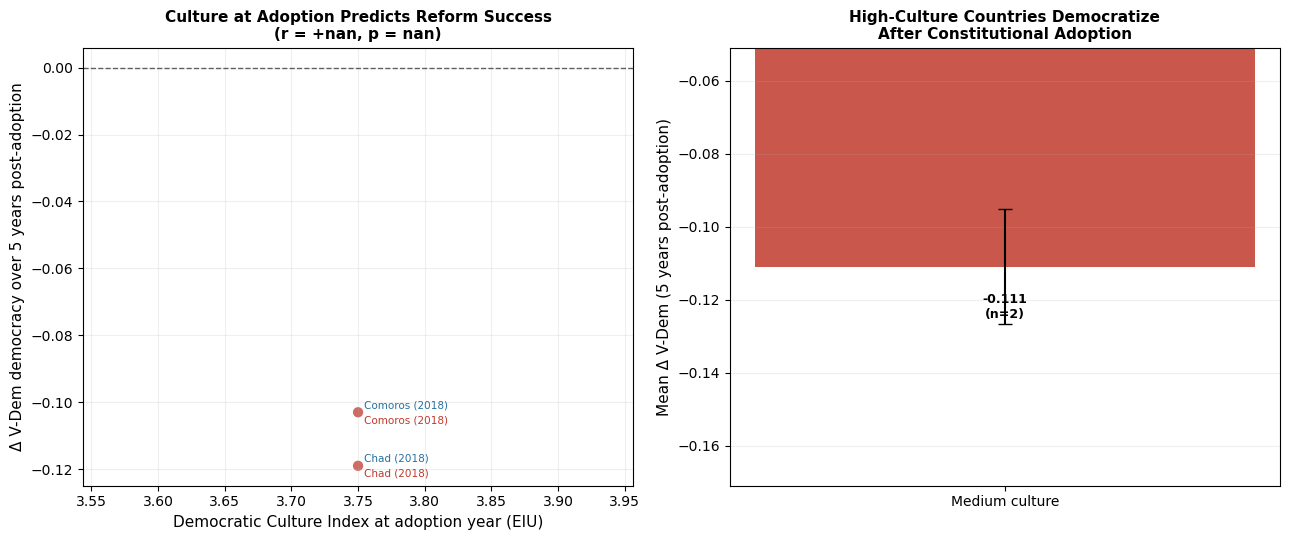

Saved: step7_reform_culture.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: scatter — culture at adoption vs 5-year democracy change
ax = axes[0]
scatter_colors = ev_clean['delta_5yr'].apply(lambda x: '#2470A0' if x > 0 else '#C0392B')
ax.scatter(ev_clean['culture_at'], ev_clean['delta_5yr'],
           c=scatter_colors, s=55, alpha=0.75, linewidths=0)
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.6)

# OLS trend line
fit = np.polyfit(ev_clean['culture_at'], ev_clean['delta_5yr'], 1)
x_line = np.linspace(ev_clean['culture_at'].min(), ev_clean['culture_at'].max(), 100)
ax.plot(x_line, np.polyval(fit, x_line), color='black', lw=2, linestyle='-', alpha=0.6)

# Label notable cases
for _, r in ev_clean.nlargest(4, 'delta_5yr').iterrows():
    ax.annotate(f'{r["country_name"]} ({r["adopt_year"]})',
                (r['culture_at'], r['delta_5yr']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', color='#2470A0')
for _, r in ev_clean.nsmallest(4, 'delta_5yr').iterrows():
    ax.annotate(f'{r["country_name"]} ({r["adopt_year"]})',
                (r['culture_at'], r['delta_5yr']),
                fontsize=7.5, xytext=(4, -8), textcoords='offset points', color='#C0392B')

ax.set_xlabel('Democratic Culture Index at adoption year (EIU)', fontsize=11)
ax.set_ylabel('Δ V-Dem democracy over 5 years post-adoption', fontsize=11)
ax.set_title(f'Culture at Adoption Predicts Reform Success\n(r = {r_cult:+.3f}, p = {p_cult:.3f})',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.2)

# Right: bar chart — mean Δ V-Dem by culture tertile
ax2 = axes[1]
tert_data = ev_clean.groupby('culture_tertile', observed=True)['delta_5yr'].agg(['mean', 'sem', 'count'])
colors_tert = ['#C0392B', '#E07B39', '#2470A0']
bars = ax2.bar(tert_data.index, tert_data['mean'], color=colors_tert, alpha=0.85,
               yerr=tert_data['sem'] * 1.96, capsize=5, error_kw={'lw': 1.5})
for bar, (_, row) in zip(bars, tert_data.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.005 if bar.get_height() >= 0 else -0.015),
             f'{row["mean"]:+.3f}\n(n={int(row["count"])})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', lw=1, linestyle='--', alpha=0.6)
ax2.set_ylabel('Mean Δ V-Dem (5 years post-adoption)', fontsize=11)
ax2.set_title('High-Culture Countries Democratize\nAfter Constitutional Adoption',
              fontsize=11, fontweight='bold')
ax2.set_ylim(tert_data['mean'].min() - 0.06, tert_data['mean'].max() + 0.06)
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('outputs/07_culture_and_constitution/reform_culture.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step7_reform_culture.png')